In [3]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

In [4]:
data = pd.read_csv("Building Energy Efficiency.csv")

In [5]:
data


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.7638,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.9800,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.9800,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.9800,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.9000,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.6400,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.6200,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.6200,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.6200,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [6]:
data.shape

(768, 10)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness       768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Heating Load               768 non-null    float64
 9   Cooling Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [8]:
data.describe()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.763885,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105490,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.820000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [9]:
data.isnull().sum()

Relative Compactness         0
Surface Area                 0
Wall Area                    0
Roof Area                    0
Overall Height               0
Orientation                  0
Glazing Area                 0
Glazing Area Distribution    0
Heating Load                 0
Cooling Load                 0
dtype: int64

In [10]:
# Feature Engineering

# Create a new feature for the ratio of Glazing Area to Floor Area
data['Glazing_Area_Ratio'] = data['Glazing Area'] / 100

# Create a new feature for the ratio of Wall Area to Roof Area
data['Wall_to_Roof_Ratio'] = data['Wall Area'] / data['Roof Area']

# Normalize numerical features using StandardScaler
numerical_features = ['Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Glazing Area', 'Heating Load', 'Cooling Load']
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [11]:
# Splitting the data into training and testing sets
X = data.drop(['Heating Load', 'Cooling Load'], axis=1)  # Features
y_heat = data['Heating Load']  # Target for heating load prediction
y_cool = data['Cooling Load']  # Target for cooling load prediction

In [12]:
X_train, X_test, y_heat_train, y_heat_test, y_cool_train, y_cool_test = train_test_split(
    X, y_heat, y_cool, test_size=0.2, random_state=42
)

In [13]:
# Cross-Validation

rf_regressor = RandomForestRegressor(random_state=42)   # Using Random Forest Regressor ML Model here
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)  # KFold Cross-Validation

accuracies=cross_val_score(estimator=rf_regressor,X=X,y=y_heat,cv=25)
accuracies

array([0.09764976, 0.93415533, 0.98726434, 0.99877265, 0.9971796 ,
       0.99796463, 0.99419828, 0.99780769, 0.99459183, 0.99624379,
       0.99811625, 0.9970113 , 0.99618402, 0.9976607 , 0.99676857,
       0.99721593, 0.99830034, 0.99824353, 0.99711678, 0.99922415,
       0.98922926, 0.99593289, 0.99518456, 0.99584199, 0.99007405])

In [14]:
accuracies.mean()

0.9575172889036315

In [15]:
cv=ShuffleSplit(n_splits=15,test_size=0.3,random_state=0)
cross_val_score(rf_regressor,X,y_cool,cv=cv)

array([0.96820845, 0.95647167, 0.96591127, 0.97304531, 0.97409938,
       0.95397946, 0.95800003, 0.95628783, 0.96746512, 0.96987477,
       0.96262017, 0.96582819, 0.96848005, 0.96031029, 0.97255859])

In [16]:
# Using the SVR ML Model for predictions here

svm_regressor = SVR(kernel='linear')  # 'linear' kernel is used
svm_regressor.fit(X_train, y_heat_train)   # fitting the model on 'y_heat' test data
svm_regressor.fit(X_train, y_cool_train)  # fitting the model on 'y_cool' test data

SVR(kernel='linear')

In [17]:
y_heat_train_pred = svm_regressor.predict(X_train)
y_cool_train_pred = svm_regressor.predict(X_train)

In [18]:
y_heat_pred = svm_regressor.predict(X_test)
print(y_heat_pred)

[-0.53047454 -0.86992943  0.8599501   1.14393364 -0.80989226  0.56472562
  0.40012451  0.62724474 -0.58492658  0.51549237 -0.56888937  1.06247777
  0.5308114  -1.26169249 -0.58205385  1.29302858  1.30005008 -1.03042349
 -0.74748969  1.06734472  1.02798179  1.1320452  -1.09218271  0.67022539
 -1.04116125  0.67509234  0.98361549  1.04258264 -0.81691376 -0.74786087
 -1.26871399 -1.02212596 -0.81061044  0.79455825  0.68267169  0.63697864
  0.87383276  0.67780474  0.98848244 -1.20244833  0.63913319 -1.03529044
 -1.35782463  0.9328486  -1.3096759  -1.35295768 -1.24269206 -1.20731528
  0.69942505  0.76351676  0.98433367 -0.8670567  -0.8546104   0.91681342
 -0.96272147 -1.03701249 -1.03185986  0.80716488  1.52645212  1.29374676
 -0.68258557 -0.52903818 -0.85245585  0.5751777   0.64400014  0.68482624
  0.67995929 -1.10191661 -0.97912986 -1.03114168  0.5237899   0.86138647
 -0.92430664  0.5681562   0.93213041 -1.02699291  1.03915205  0.79599461
  0.85851373  0.30719463  0.39669393  0.90221257 -1

In [19]:
y_cool_pred = svm_regressor.predict(X_test)
print(y_cool_pred)

[-0.53047454 -0.86992943  0.8599501   1.14393364 -0.80989226  0.56472562
  0.40012451  0.62724474 -0.58492658  0.51549237 -0.56888937  1.06247777
  0.5308114  -1.26169249 -0.58205385  1.29302858  1.30005008 -1.03042349
 -0.74748969  1.06734472  1.02798179  1.1320452  -1.09218271  0.67022539
 -1.04116125  0.67509234  0.98361549  1.04258264 -0.81691376 -0.74786087
 -1.26871399 -1.02212596 -0.81061044  0.79455825  0.68267169  0.63697864
  0.87383276  0.67780474  0.98848244 -1.20244833  0.63913319 -1.03529044
 -1.35782463  0.9328486  -1.3096759  -1.35295768 -1.24269206 -1.20731528
  0.69942505  0.76351676  0.98433367 -0.8670567  -0.8546104   0.91681342
 -0.96272147 -1.03701249 -1.03185986  0.80716488  1.52645212  1.29374676
 -0.68258557 -0.52903818 -0.85245585  0.5751777   0.64400014  0.68482624
  0.67995929 -1.10191661 -0.97912986 -1.03114168  0.5237899   0.86138647
 -0.92430664  0.5681562   0.93213041 -1.02699291  1.03915205  0.79599461
  0.85851373  0.30719463  0.39669393  0.90221257 -1

In [20]:
mse_train = mean_squared_error(y_heat_train, y_heat_train_pred)
mse_test = mean_squared_error(y_heat_test, y_heat_pred)
bias = np.mean((y_heat_train - np.mean(y_heat_train_pred))**2)
variance = np.mean([((y - np.mean(y_heat_train_pred)) ** 2) for y in y_heat_train_pred])
print(f"Mean Squared Error (Training): {mse_train}")
print(f"Mean Squared Error (Testing): {mse_test}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Mean Squared Error (Training): 0.09405033883824335
Mean Squared Error (Testing): 0.10255039182230839
Bias: 0.9942371216468958
Variance: 0.8260583810779484


In [21]:
# on 'y_cool' test data
from sklearn.metrics import accuracy_score

mse_train = mean_squared_error(y_cool_train, y_cool_train_pred)
mse_test = mean_squared_erroest, y_cool_pred)
bias = np.mean((y_cool_train - np.mean(y_cool_train_pred))**2)
variance = np.mean([((y - np.mean(y_cool_train_pred)) ** 2) for y in y_cool_train_pred])
print(f"Mean Squared Error (Training): {mse_train}")
print(f"Mean Squared Error (Testing): {mse_test}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

SyntaxError: unmatched ')' (3534084469.py, line 5)

In [26]:
X = data[['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution']]
Y = data[['Heating Load', 'Cooling Load']]
Y1= data[['Heating Load']]
Y2= data[['Cooling Load']]

In [27]:
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(X, Y1, Y2, test_size=0.33, random_state = 20)

In [28]:
#creating an empty dataframe 'Acc' to store the results
Acc = pd.DataFrame(index=None, columns=['model','train_Heating','test_Heating','train_Cooling','test_Cooling'])

In [29]:
#list of regressor models
regressors = [['DecisionTreeRegressor',DecisionTreeRegressor()],
              ['RandomForestRegressor', RandomForestRegressor()],
              ['GradientBoostingRegressor',GradientBoostingRegressor()]]

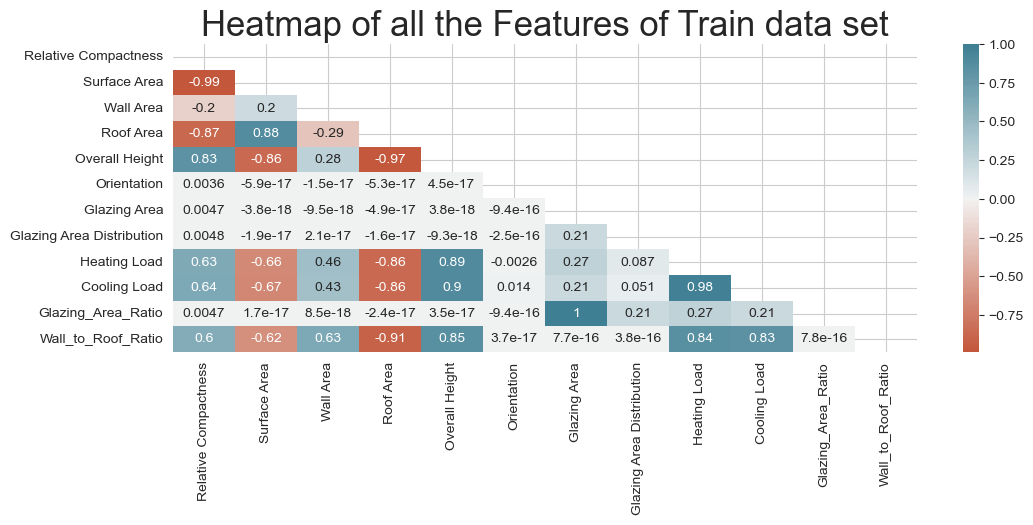

In [30]:
import matplotlib.pyplot as plt

import matplotlib.style as style

import seaborn as sns

style.use('ggplot')

sns.set_style('whitegrid')

plt.subplots(figsize = (12,4))

mask = np.zeros_like(data.corr(), dtype=bool)

mask[np.triu_indices_from(mask)] = True

sns.heatmap(data.corr(), cmap=sns.diverging_palette (20, 220, n=200), annot= True, mask=mask, center = 0, );

plt.title("Heatmap of all the Features of Train data set", fontsize = 25);

In [31]:
for mod in regressors:               #function to iterate through the regressors,
                                    # fits the models to training data,
                                    #and calculates R-squared scores for both training and test sets for heating and cooling loads.
                                    #The results are then added to the Acc DataFrame.
    name = mod[0]
    model = mod[1]

    model.fit(X_train,y1_train)
    actr1 = r2_score(y1_train, model.predict(X_train))
    acte1 = r2_score(y1_test, model.predict(X_test))

    model.fit(X_train,y2_train)
    actr2 = r2_score(y2_train, model.predict(X_train))
    acte2 = r2_score(y2_test, model.predict(X_test))

    Acc = Acc.append(pd.Series({'model':name, 'train_Heating':actr1,'test_Heating':acte1,'train_Cooling':actr2,'test_Cooling':acte2}),ignore_index=True )
Acc.sort_values(by='test_Cooling')

C:\Users\adity\AppData\Local\Temp\ipykernel_1028\2696316317.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  Acc = Acc.append(pd.Series({'model':name, 'train_Heating':actr1,'test_Heating':acte1,'train_Cooling':actr2,'test_Cooling':acte2}),ignore_index=True )
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\adity\AppData\Local\Temp\ipykernel_1028\2696316317.py:16: FutureWarning: The frame.append method is dep

,model,train_Heating,test_Heating,train_Cooling,test_Cooling
0,DecisionTreeRegressor,1.000000,0.997179,1.000000,0.942659
1,RandomForestRegressor,0.999378,0.997508,0.995499,0.963911
2,GradientBoostingRegressor,0.998173,0.997641,0.979423,0.976044


In [32]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y1_train)


DecisionTreeRegressor(random_state=42)

In [33]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y2_train)

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [34]:
dt_predictions = dt_regressor.predict(X_test)
rf_predictions = rf_regressor.predict(X_test)

In [35]:
dt_mse = mean_squared_error(y1_test, dt_predictions)
rf_mse = mean_squared_error(y1_test, rf_predictions)
print("Decision Tree Regressor MSE:", dt_mse)
print("Random Forest Regressor MSE:", rf_mse)

Decision Tree Regressor MSE: 0.0028062320389116357
Random Forest Regressor MSE: 0.02594200732993782


In [36]:
dt_mse = mean_squared_error(y2_test, dt_predictions)
rf_mse = mean_squared_error(y2_test,  rf_predictions)
print("Decision Tree Regressor MSE:", dt_mse)
print("Random Forest Regressor MSE:", rf_mse)

Decision Tree Regressor MSE: 0.03782662391184528
Random Forest Regressor MSE: 0.03738816658304324


In [37]:
gb_regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_regressor.fit(X_train, y1_train)

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor(random_state=42)

In [38]:
gb_predictions = gb_regressor.predict(X_test)
rf_predictions = rf_regressor.predict(X_test)

In [39]:
gb_mse = mean_squared_error(y1_test, gb_predictions)
rf_mse = mean_squared_error(y1_test, rf_predictions)
print("Gradient Boosting Regressor MSE:", gb_mse)
print("Random Forest Regressor MSE:", rf_mse)

Gradient Boosting Regressor MSE: 0.0023916667124549646
Random Forest Regressor MSE: 0.02594200732993782


In [40]:
gb_mse = mean_squared_error(y2_test, gb_predictions)
rf_mse = mean_squared_error(y2_test, rf_predictions)
print("Gradient Boosting Regressor MSE:", gb_mse)
print("Random Forest Regressor MSE:", rf_mse)

Gradient Boosting Regressor MSE: 0.03756461792333449
Random Forest Regressor MSE: 0.03738816658304324


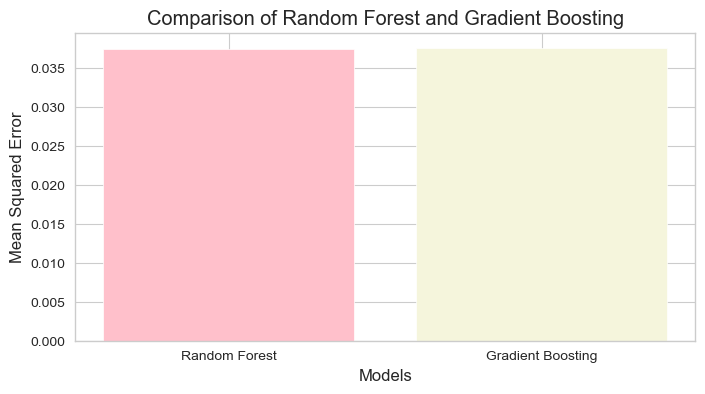

In [41]:
models = ['Random Forest', 'Gradient Boosting']
mse_scores = [rf_mse, gb_mse]

plt.figure(figsize=(8, 4))
plt.bar(models, mse_scores, color=['pink', 'beige'])
plt.xlabel('Models')
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Random Forest and Gradient Boosting')
plt.show()

NameError: name 'y_test' is not defined

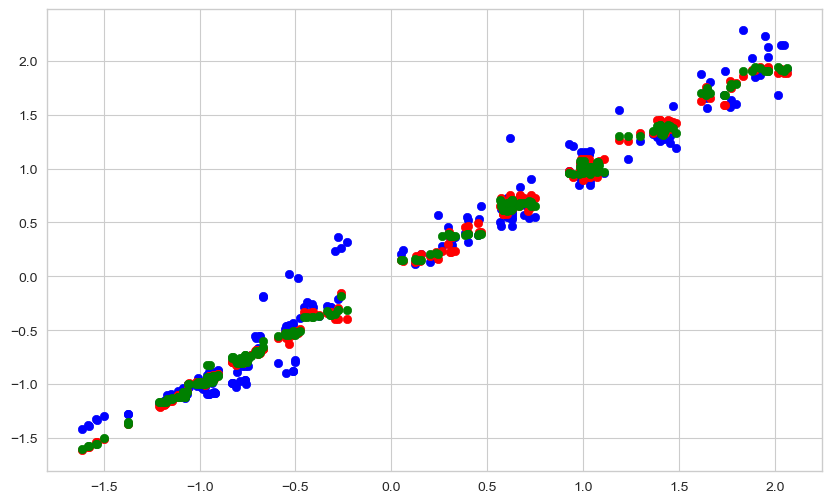

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(y1_test, rf_predictions, color='blue', label=f'Random Forest (MSE: {rf_mse:.2f})')
plt.scatter(y1_test, dt_predictions, color='red', label=f'Decision Tree (MSE: {dt_mse:.2f})')
plt.scatter(y1_test, gb_predictions, color='green', label=f'Gradient Boosting (MSE: {gb_mse:.2f})')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Comparison of Regression Models')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y1_train)
svr_predictions = svr_model.predict(X_test_scaled)
svr_rmse = mean_squared_error(y1_test, svr_predictions, squared=False)

C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [47]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y1_train)
dt_predictions = dt_model.predict(X_test)
dt_rmse = mean_squared_error(y1_test, dt_predictions, squared=False)

In [48]:
print("SVR RMSE:", svr_rmse)
print("Decision Tree RMSE:", dt_rmse)

SVR RMSE: 0.24918270552812918
Decision Tree RMSE: 0.05297388072353804


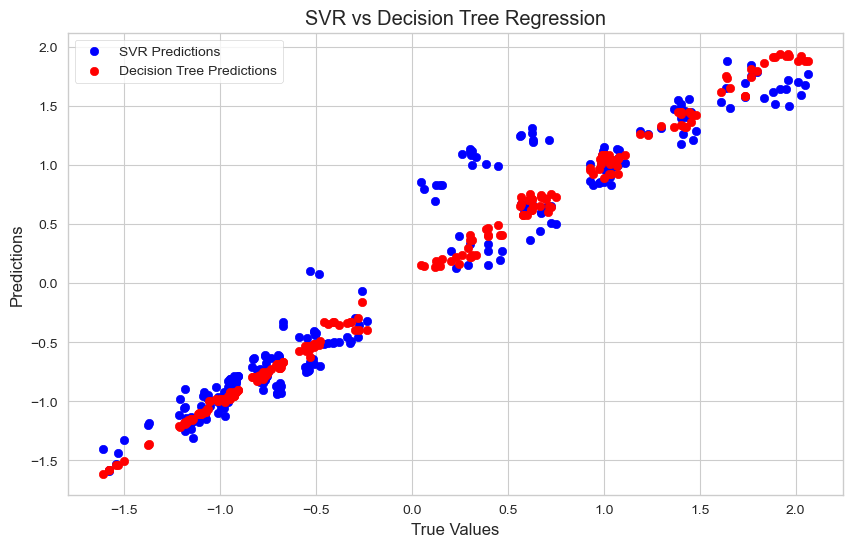

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(y1_test, svr_predictions, color='blue', label='SVR Predictions')
plt.scatter(y1_test, dt_predictions, color='red', label='Decision Tree Predictions')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVR vs Decision Tree Regression')
plt.legend()
plt.show()